In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import END, START
from langgraph.graph.state import StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langchain_core.tools import tool
from langchain_core.messages import BaseMessage
import os
from dotenv import load_dotenv
load_dotenv() 

True

In [2]:
os.environ["LANGSMITH_PROJECT"] = "TestProject"

In [3]:
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGCHAIN_API_KEY") #LANGCHAIN project will understand where exactly to go and track based on this api key.
os.environ["LANGSMITH_TRACING"] = "true"

  

In [4]:
from langchain.chat_models import init_chat_model
llm = init_chat_model("groq:openai/gpt-oss-120b")
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x10dbed010>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x10df50f10>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [5]:
class State(TypedDict):
#at every conversation when passing from one node to the other node all info will
#be start getting saved over baseMessage and will be available in the variable messages
    messages: Annotated[list[BaseMessage], add_messages]

In [6]:
#Graph with tool call
from langchain_core.tools import tool

@tool
def add(a: float, b:float):
    """Add the two numbers"""
    return a+b
tools   = [add]
tool_node = ToolNode([add])

llm_with_tool = llm.bind_tools([add])

def call_llm_model(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}


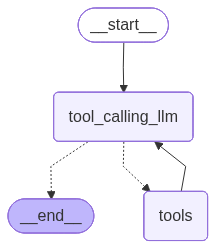

In [7]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

#Node definition
def call_llm_model(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}


## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",call_llm_model)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))



In [8]:
response = graph.invoke({"messages": "What is machine learning?"})

In [9]:
response

{'messages': [HumanMessage(content='What is machine learning?', additional_kwargs={}, response_metadata={}, id='bdba4e57-fb49-441d-aefa-4e7f9d6954ae'),
  AIMessage(content='**Machine learning (ML)** is a branch of artificial intelligence (AI) that focuses on giving computers the ability to learn from data and improve their performance on a task without being explicitly programmed for every possible scenario.\n\n### Core Idea\n- **Learning from Data:** Instead of writing step‑by‑step instructions, we feed a computer a large collection of examples (the *training data*). The computer uses statistical methods to find patterns, relationships, or rules within that data.\n- **Model:** The result of this learning process is a *model*—a mathematical representation (e.g., a set of parameters) that can make predictions or decisions on new, unseen data.\n- **Improvement Over Time:** As more data become available or as the model is refined (through techniques like hyper‑parameter tuning, additional

In [10]:
response = graph.invoke({"messages": "What is 500 plus 20908?"})

In [11]:
response

{'messages': [HumanMessage(content='What is 500 plus 20908?', additional_kwargs={}, response_metadata={}, id='ee0ce79d-b3dc-4edc-bcf2-42750543489c'),
  AIMessage(content='The sum of 500 and 20,908 is **21,408**.', additional_kwargs={'reasoning_content': 'We need to compute 500+20908 = 21408. Provide answer.'}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 130, 'total_tokens': 174, 'completion_time': 0.096260128, 'completion_tokens_details': {'reasoning_tokens': 18}, 'prompt_time': 0.006855411, 'prompt_tokens_details': None, 'queue_time': 0.156373297, 'total_time': 0.103115539}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_c15aa9c1b7', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cd7ac-3296-7ea3-b643-e4f06fd5d103-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 130, 'output_tokens': 44, 'total_tokens': 174, 'output_token_details': {'reasoning': 1